# EPCRC results — every claim, every number

This notebook is the results package. It displays exactly what the delivered
zip contains, because both call the same two modules:

- `epcrc/report.py` turns raw experiment JSON into tables
- `epcrc/figures.py` draws those tables

Nothing here recomputes an experiment. If a number is wrong, it is wrong in the
JSON and the experiment has to be rerun. That is deliberate: a notebook that
quietly recomputes its own version of a result is how a figure and a CSV end up
disagreeing.

Set `PANEL` below to `"core8"` (smoke panel) or `"core20"` (the formal panel).

In [1]:
%matplotlib inline
import os, sys
import numpy as np
import pandas as pd

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, ROOT)

from epcrc import report as R
from epcrc import figures as F
from experiments.export_results import input_paths

PANEL = "core8"

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

PATHS = input_paths(PANEL)
for key, path in PATHS.items():
    mark = "found  " if os.path.exists(path) else "MISSING"
    print(f"{mark}  {key:<14} {os.path.relpath(path, ROOT)}")

found    e0_synthetic   results/e0_noncomposability.json
found    e0_real        results/e0_real_core8.json
found    e1             results/e1_frontier.json
found    c3             results/c3_baselines.json


In [2]:
payload = R.load(PATHS["c3"])
block = payload["per_split_seed"][0]

print(f"judges            {len(block['judges'])}: {', '.join(block['judges'])}")
print(f"contexts          {len(block['contexts'])}: {', '.join(block['contexts'])}")
print(f"items per split   " + ", ".join(f"{k} {v}" for k, v in block["split_items"].items()))
print(f"split seeds       {payload['split_seeds']}")
print(f"bootstrap reps    {payload['n_bootstrap']}")
print()
print("Splits are grouped by source item, so no prompt appears in two splits.")
print("The pairs seed fixes what each judge saw and needs GPU time to change;")
print("the split seed only re-partitions the cached responses, which is free.")

judges            8: J02, J05, J08, J10, J12, J14, J16, J20
contexts          7: I0_clean, I1_order_swap, I2_correctness_rubric, I3_bias_resistant_rubric, I4_verbosity_pad_a, I5_source_tags, I6_reference_hidden
items per split   FIT 54, CERT 24, TEST 22
split seeds       [20260818, 20260819, 20260820, 20260821, 20260822]
bootstrap reps    2000

Splits are grouped by source item, so no prompt appears in two splits.
The pairs seed fixes what each judge saw and needs GPU time to change;
the split seed only re-partitions the cached responses, which is free.


---

## Claim C1 — individual redundancy certificates do not compose

> A judge certified removable on its own need not be removable alongside other
> judges that were each certified the same way.

**How it is tested.** For a tolerance $\gamma$, collect
$R(\gamma) = \{i : U(i \mid J \setminus \{i\}) \le \gamma\}$ — every judge
whose leave-one-out reconstruction error is within tolerance. Delete all of
$R(\gamma)$ at once and measure what the surviving panel achieves.

If certificates composed, the joint error would still be at most $\gamma$.

In [3]:
c1 = R.c1_table(PATHS["e0_real"])
loo = c1[["loo_min", "loo_median", "loo_max"]].agg(["min", "median", "max"])
print("leave-one-out error across judges and split seeds")
print(f"  min {c1['loo_min'].min():.4f}   median {c1['loo_median'].median():.4f}   max {c1['loo_max'].max():.4f}")

declared = R.c1_headline(PATHS["e0_real"], gamma_source="declared")
print()
print("predeclared gamma grid (plan section 23)")
display(declared)

leave-one-out error across judges and split seeds
  min 0.2410   median 0.3928   max 0.7185

predeclared gamma grid (plan section 23)


,instance,gamma,removable,naive_size,naive_coverage,min_feasible,composition_gap,cycles,seeds,naive_set_fails
0,core8_real,0.0200,0.0000,8.0000,0.0000,8.0000,0.0000,1.0000,5,False
1,core8_real,0.0400,0.0000,8.0000,0.0000,8.0000,0.0000,1.0000,5,False
2,core8_real,0.0600,0.0000,8.0000,0.0000,8.0000,0.0000,1.0000,5,False
3,core8_real,0.0800,0.0000,8.0000,0.0000,8.0000,0.0000,1.0000,5,False
4,core8_real,0.1000,0.0000,8.0000,0.0000,8.0000,0.0000,1.0000,5,False
5,core8_real,0.1200,0.0000,8.0000,0.0000,8.0000,0.0000,1.0000,5,False
6,core8_real,0.1500,0.0000,8.0000,0.0000,8.0000,0.0000,1.0000,5,False
7,core8_real,0.2000,0.0000,8.0000,0.0000,8.0000,0.0000,1.0000,5,False


If every leave-one-out error sits above the largest predeclared tolerance, then
$R(\gamma)$ is empty across that whole grid and C1 has nothing to say on it.
That is a property of the panel, not a result, and it is reported rather than
worked around.

$R(\gamma)$ only changes when $\gamma$ crosses a leave-one-out error, so the
sorted leave-one-out errors are the *complete* set of informative tolerances.
Those are used below and are labelled data-driven everywhere they appear.

In [4]:
breaks = c1[(c1["gamma_source"] == "loo_breakpoint") & (c1["n_individually_removable"] >= 2)]

n_viol = int(breaks["naive_violates_gamma"].sum())
print(f"cases where >=2 judges were each individually certified removable : {len(breaks)}")
print(f"  of which the joint deletion broke the tolerance                 : {n_viol}"
      f"  ({100 * n_viol / len(breaks):.0f}%)")
print(f"  mean composition gap (extra judges the joint constraint needs)   : {breaks['composition_gap'].mean():+.2f}")
print()

worst = breaks.loc[breaks["naive_coverage"].replace(np.inf, np.nan).idxmax()]
print(f"worst finite case: at gamma = {worst['gamma']:.3f}, "
      f"{int(worst['n_individually_removable'])} judges each passed their own test,")
print(f"  yet deleting them together gave error {worst['naive_coverage']:.3f}, "
      f"and the smallest feasible panel needs {int(worst['min_feasible_size'])} judges.")

cases where >=2 judges were each individually certified removable : 35
  of which the joint deletion broke the tolerance                 : 35  (100%)
  mean composition gap (extra judges the joint constraint needs)   : +1.40

worst finite case: at gamma = 0.565, 7 judges each passed their own test,
  yet deleting them together gave error 0.922, and the smallest feasible panel needs 3 judges.


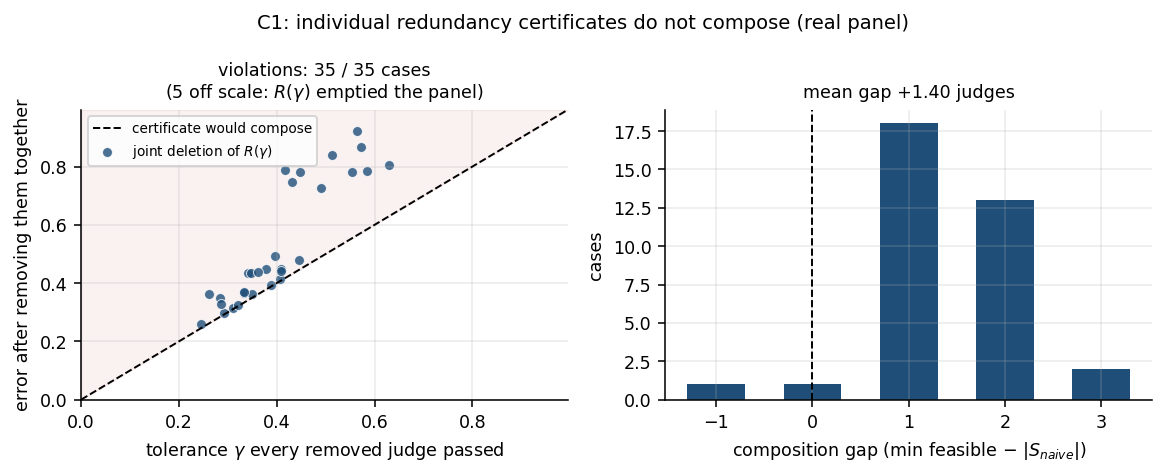

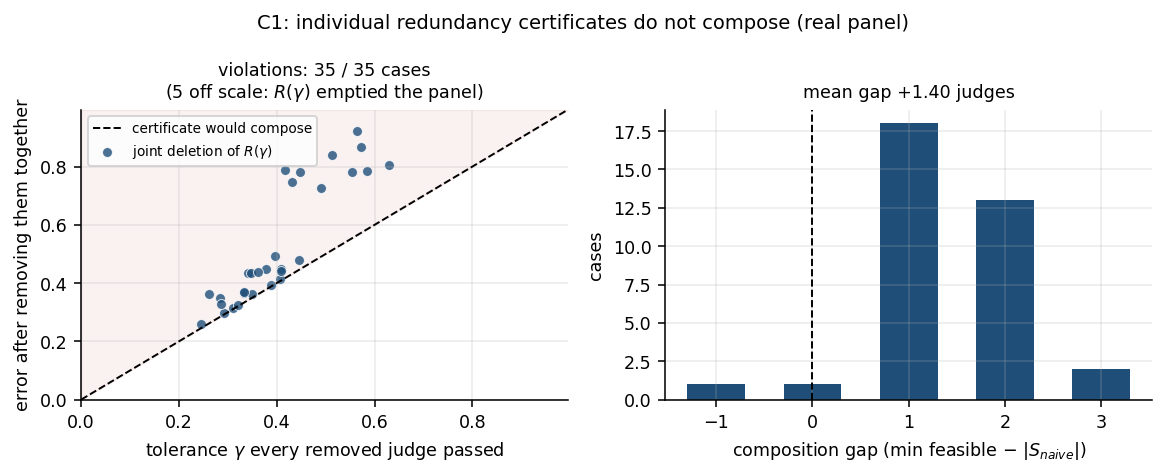

In [5]:
display(F.fig_c1_real(PATHS["e0_real"]))

### The same claim where the answer is known in advance

Two controlled constructions. `duplicated_extremes` contains exact duplicates,
so each copy is individually redundant but the pair is not. `curved_arc_9`
places judges on a curve where every judge is nearly interpolated by its
neighbours.

,instance,gamma,removable,naive_size,naive_coverage,min_feasible,composition_gap,cycles,seeds,naive_set_fails
0,curved_arc_9,0.0020,0.0000,9.0000,0.0000,9.0000,0.0000,1.0000,5,False
1,curved_arc_9,0.0050,7.0000,2.0000,0.0551,5.0000,3.0000,1.0000,5,True
2,curved_arc_9,0.0100,7.0000,2.0000,0.0551,4.0000,2.0000,1.0000,5,True
3,curved_arc_9,0.0200,7.0000,2.0000,0.0551,3.0000,1.0000,1.0000,5,True
4,curved_arc_9,0.0400,9.0000,0.0000,inf,2.0000,2.0000,1.0000,5,True
5,curved_arc_9,0.0800,9.0000,0.0000,inf,2.0000,2.0000,1.0000,5,True
6,duplicated_extremes,0.0020,6.0000,0.0000,inf,3.0000,3.0000,3.0000,5,True
7,duplicated_extremes,0.0050,6.0000,0.0000,inf,3.0000,3.0000,3.0000,5,True
8,duplicated_extremes,0.0100,6.0000,0.0000,inf,3.0000,3.0000,3.0000,5,True
9,duplicated_extremes,0.0200,6.0000,0.0000,inf,3.0000,3.0000,3.0000,5,True


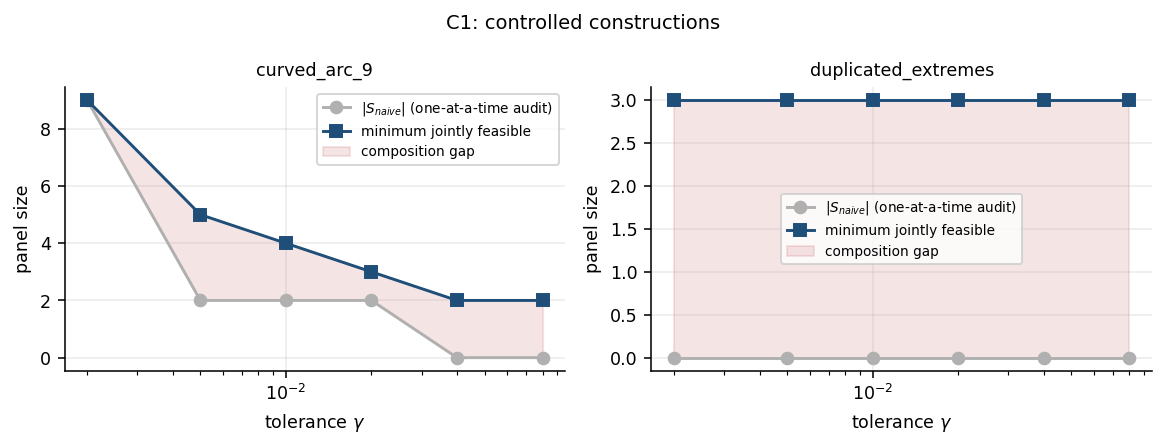

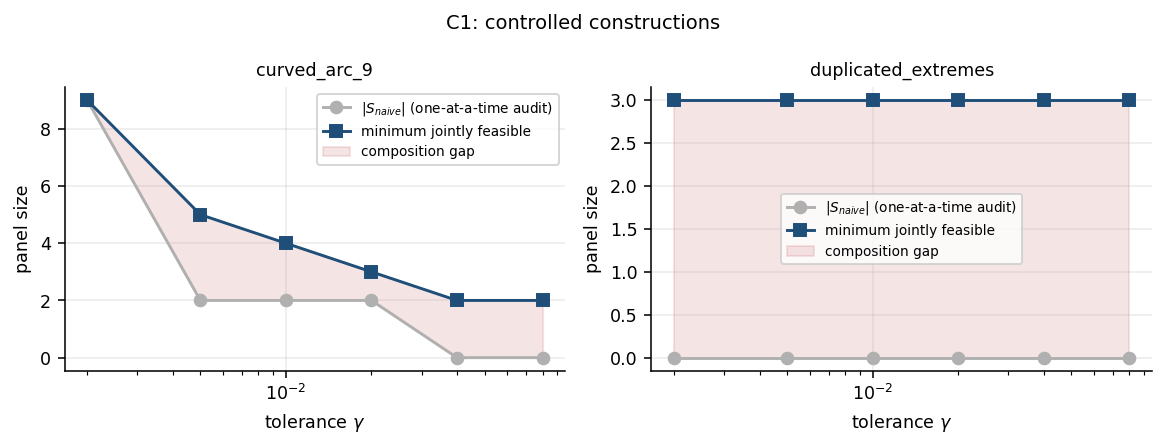

In [6]:
syn = R.c1_headline(PATHS["e0_synthetic"], gamma_source=None)
display(syn)
display(F.fig_c1_synthetic(PATHS["e0_synthetic"]))

---

## Claim C2 — the physical-to-virtual compression frontier

> A small physical panel reconstructs every virtual judge to within a small
> worst-context error on held-out items.

**How it is tested.** For each budget $k$, pick a physical subset $S$, fit one
simplex weight vector $w^{(j)}$ per judge on FIT, and score those weights on the
locked TEST split. Weights are never fitted on the split they are scored on.

The headline is the **worst** judge in its **worst** context, not the average —
C2 is a statement about every judge being preserved.

In [7]:
c2 = R.c2_table(PATHS["e1"], "TEST")
cov = c2[c2["method"] == "coverage_backward"].sort_values("k")
display(cov[["k", "worst_judge_tv", "mean_judge_tv", "median_item_tv",
             "p95_item_tv", "verdict_agreement", "calls_avoided_frac"]])

,k,worst_judge_tv,mean_judge_tv,median_item_tv,p95_item_tv,verdict_agreement,calls_avoided_frac
0,1,0.8901,0.6252,0.6676,0.9883,0.3206,0.8750
1,2,0.6610,0.3183,0.1403,0.8049,0.7248,0.7500
2,3,0.3816,0.2148,0.0946,0.6255,0.8157,0.6250
3,4,0.3534,0.1578,0.0006,0.5858,0.8872,0.5000
4,5,0.3175,0.1063,0.0000,0.4259,0.9067,0.3750
5,6,0.3043,0.0654,0.0000,0.2669,0.9505,0.2500
6,7,0.2186,0.0273,0.0000,0.1281,0.9943,0.1250
7,8,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000


In [8]:
half = cov[cov["k"] <= max(1, int(cov["k"].max()) // 2)].iloc[-1]
print(f"at k = {int(half['k'])} of {int(cov['k'].max())} judges "
      f"({half['calls_avoided_frac']:.0%} of judge calls avoided):")
print(f"  median item TV        {half['median_item_tv']:.4f}")
print(f"  95th percentile TV    {half['p95_item_tv']:.4f}")
print(f"  verdict agreement     {half['verdict_agreement']:.1%}")
print(f"  worst judge, worst ctx {half['worst_judge_tv']:.4f}   <- what C2 is stated over")
print()
print("The typical item compresses well. The worst-judge worst-context error is")
print("the number the claim is about, and it is reported as measured.")

at k = 4 of 8 judges (50% of judge calls avoided):
  median item TV        0.0006
  95th percentile TV    0.5858
  verdict agreement     88.7%
  worst judge, worst ctx 0.3534   <- what C2 is stated over

The typical item compresses well. The worst-judge worst-context error is
the number the claim is about, and it is reported as measured.


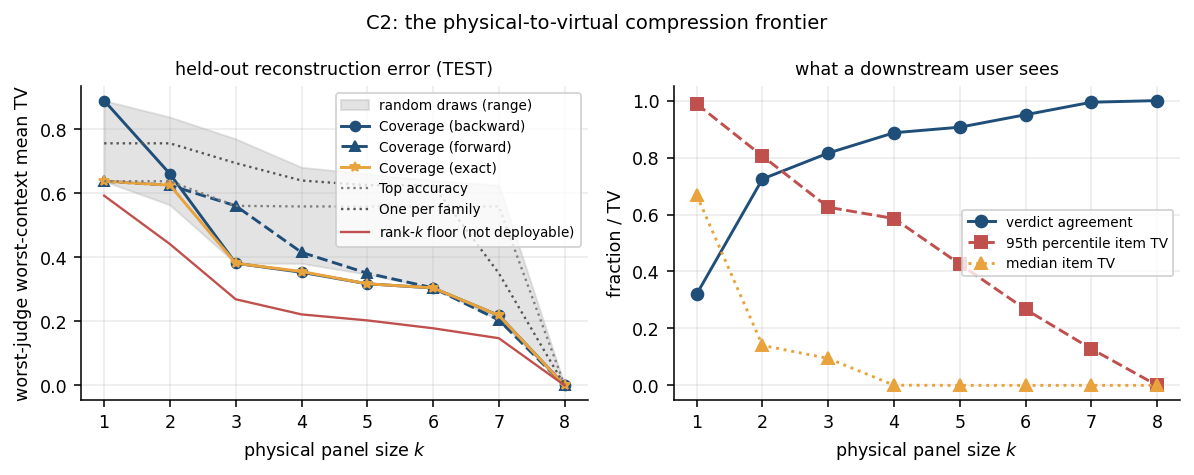

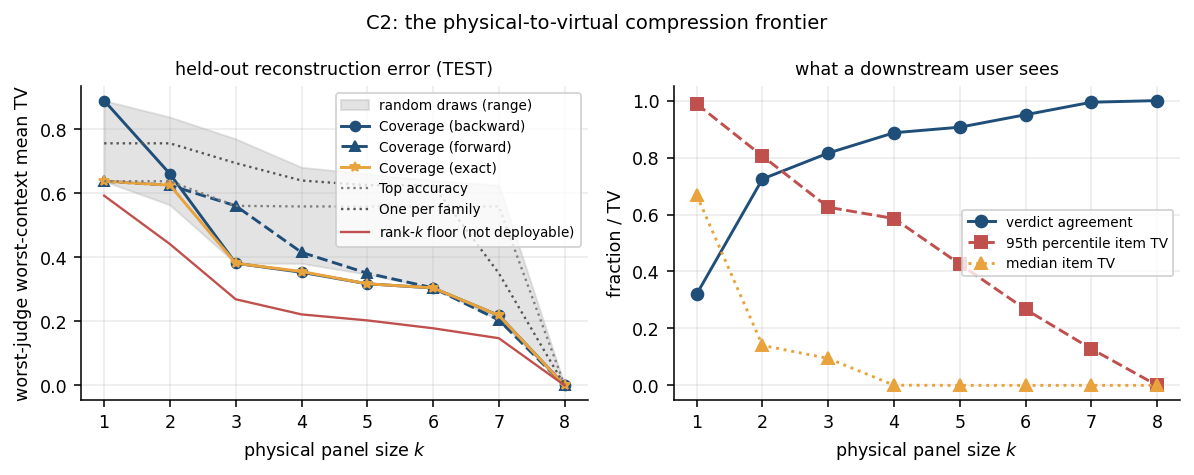

In [9]:
display(F.fig_c2_frontier(PATHS["e1"], PATHS["c3"]))

---

## Claim C3 — coverage-based selection beats the baselines

> Choosing the physical panel by the coverage functional does better than
> accuracy ranking, random choice, family diversity, cost heuristics, and
> standard pairwise-geometry selection.

**How it is tested.** Equal panel size $k$ for every method, averaged over the
non-trivial budgets and over all split seeds, with an item cluster bootstrap.
Trivial budgets are excluded: at $k = 1$ no convex combination exists, and at
$k = N$ every judge reconstructs itself exactly for every method, so no method
can differ there.

In [10]:
head = R.c3_headline(PATHS["c3"])
print(f"averaged over k in {head['k_values'].iloc[0]} and "
      f"{len(payload['split_seeds'])} split seeds, {payload['n_bootstrap']} bootstrap replicates")
print()
display(head[["label", "worst_judge_tv", "boot_lo", "boot_hi",
              "mean_judge_tv", "verdict_agreement", "p95_item_tv"]])

averaged over k in [2, 3, 4, 5, 6, 7] and 5 split seeds, 2000 bootstrap replicates



,label,worst_judge_tv,boot_lo,boot_hi,mean_judge_tv,verdict_agreement,p95_item_tv
0,Coverage (backward),0.4043,0.3536,0.4973,0.1558,0.8704,0.5091
1,Coverage (forward),0.4345,0.3729,0.5289,0.1608,0.8758,0.5057
2,Coverage (exact),0.3924,0.3414,0.4895,0.1550,0.8744,0.4981
3,Top accuracy,0.5811,0.5002,0.6817,0.1973,0.8202,0.6728
4,Random,0.5692,0.5035,0.6608,0.1983,0.8241,0.6289
5,One per family,0.6423,0.5777,0.7276,0.2196,0.8034,0.6871
6,Cheapest first,0.5626,0.5132,0.6523,0.2058,0.7938,0.6208
7,Largest first,0.6474,0.5454,0.7574,0.1927,0.8684,0.6812
8,Correlation clustering,0.4660,0.4053,0.5541,0.1663,0.8923,0.5106
9,k-medoids,0.4978,0.4199,0.5927,0.1687,0.8751,0.5380


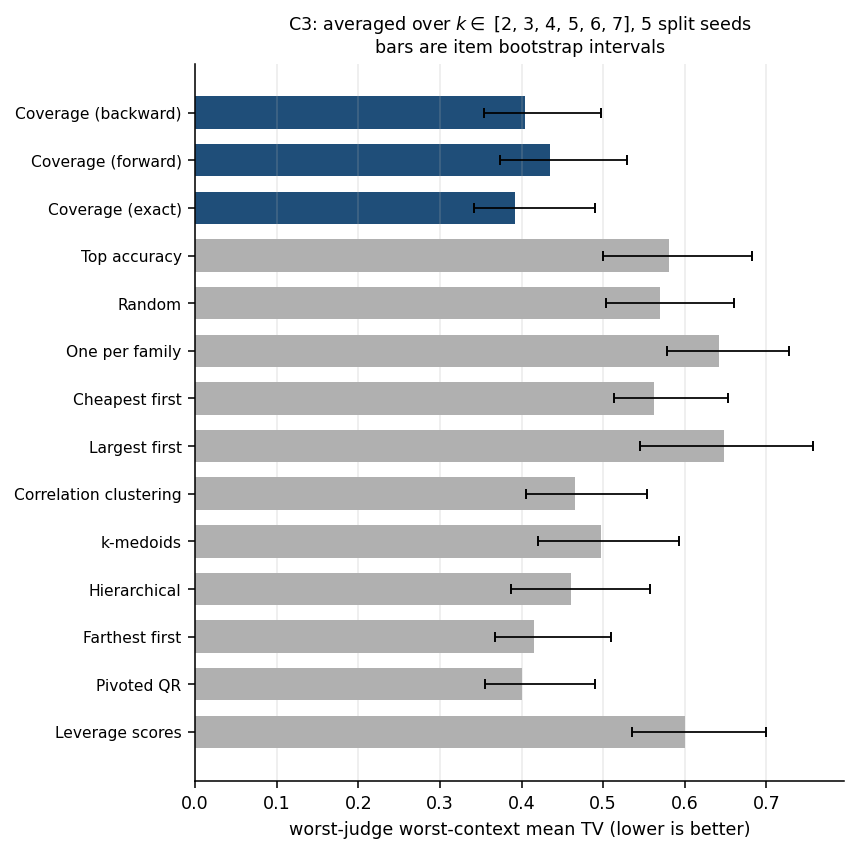

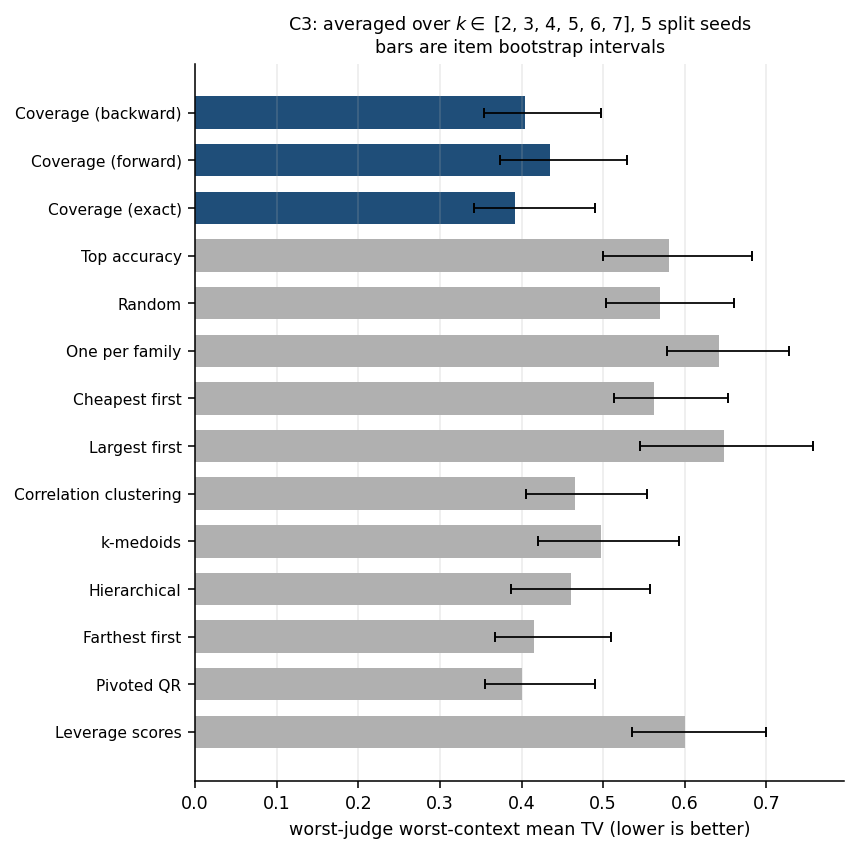

In [11]:
display(F.fig_c3_headline(PATHS["c3"]))

### The bars above overlap. That is the wrong test.

Each bar was computed on its own bootstrap. But every method is scored on the
*same* items, so most of the sampling noise is shared, and asking whether two
independent intervals overlap throws that shared noise away.

Plan section 34.2 asks for the paired version: resample the same items for both
methods and take the difference. Negative means coverage wins. `significant`
counts the (split seed, panel size) cells whose whole interval excludes zero.

,label,delta,lo,hi,significant,cells
2,Largest first,-0.2339,-0.3512,-0.1087,26,30
9,One per family,-0.2328,-0.3243,-0.1361,26,30
8,Leverage scores,-0.1946,-0.2910,-0.0949,23,30
12,Top accuracy,-0.1700,-0.2757,-0.0556,24,30
1,Cheapest first,-0.1591,-0.2416,-0.0800,24,30
7,k-medoids,-0.0849,-0.1658,-0.0009,16,30
0,Correlation clustering,-0.0568,-0.1277,0.0193,14,30
6,Hierarchical,-0.0496,-0.1217,0.0267,11,30
3,Coverage (forward),-0.0264,-0.0797,0.0302,8,30
5,Farthest first,-0.0135,-0.0433,0.0124,4,30


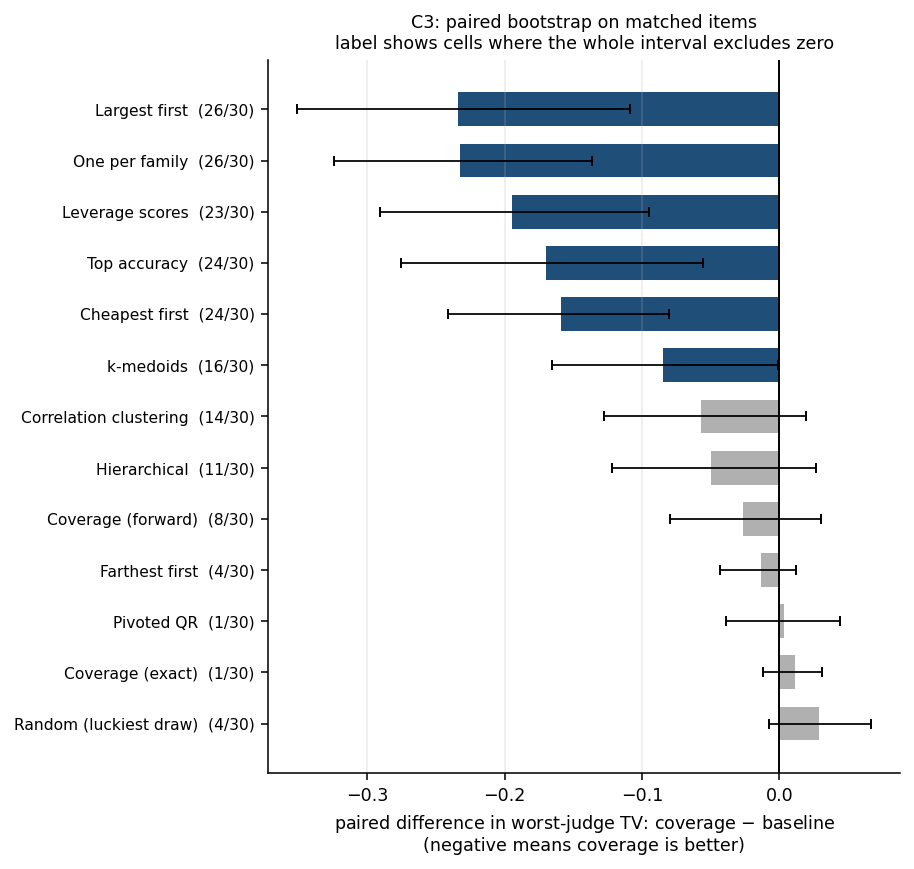

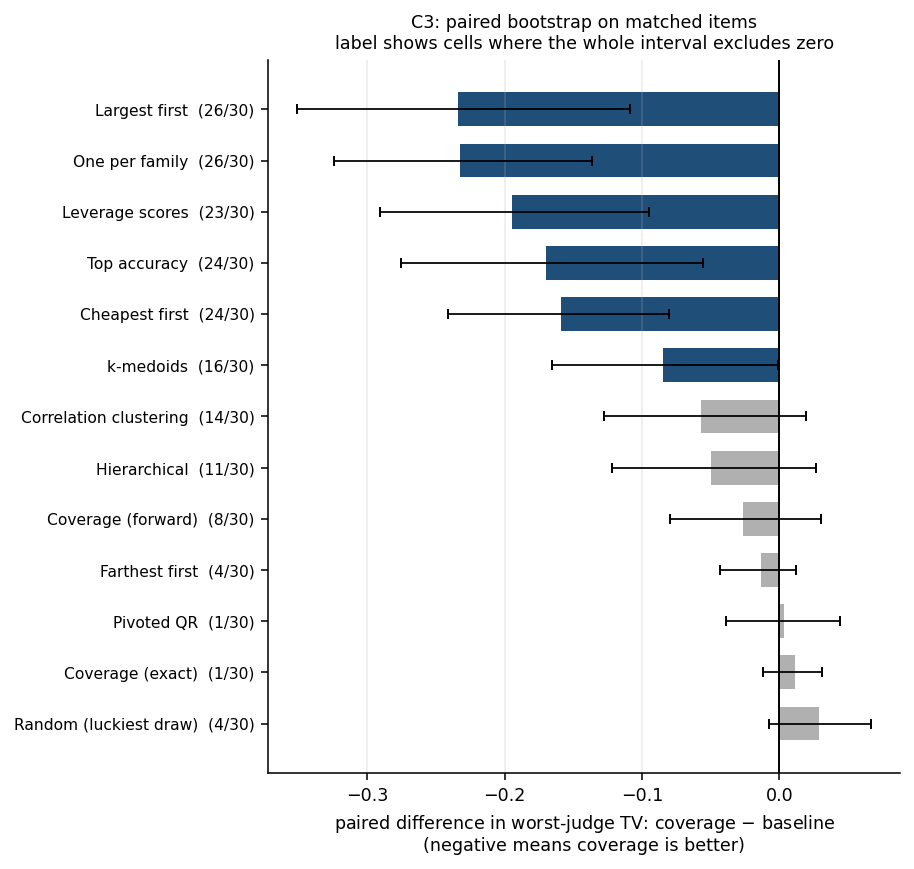

In [12]:
paired = R.c3_paired_table(PATHS["c3"])
pooled = (paired.groupby(["method", "label"], as_index=False)
          .agg(delta=("delta", "mean"), lo=("lo", "mean"), hi=("hi", "mean"),
               significant=("n_seeds_significant", "sum"), cells=("n_seeds", "sum"))
          .sort_values("delta"))
display(pooled[["label", "delta", "lo", "hi", "significant", "cells"]])
display(F.fig_c3_paired(PATHS["c3"]))

In [13]:
total = int(pooled["cells"].iloc[0])
decided = pooled[(pooled["significant"] >= 0.5 * total)
                 & (pooled["method"] != "random_best_draw")]
ties = pooled[(pooled["significant"] <= 0.2 * total)
              & (~pooled["method"].isin(R.COVERAGE_METHODS))
              & (pooled["method"] != "random_best_draw")]

print("coverage wins on a majority of cells against:")
for _, row in decided.iterrows():
    print(f"  {row['label']:<24} {row['delta']:+.3f}   {int(row['significant'])}/{total}")
print()
print("not separated from coverage on this panel:")
for _, row in ties.iterrows():
    print(f"  {row['label']:<24} {row['delta']:+.3f}   {int(row['significant'])}/{total}")
print()
print("Those are pairwise-geometry selectors, and at N=8 they often pick the")
print("identical subset, so there is nothing for the test to resolve. Whether")
print("coverage separates from them is what Core-20 has to settle.")

coverage wins on a majority of cells against:
  Largest first            -0.234   26/30
  One per family           -0.233   26/30
  Leverage scores          -0.195   23/30
  Top accuracy             -0.170   24/30
  Cheapest first           -0.159   24/30
  k-medoids                -0.085   16/30

not separated from coverage on this panel:
  Farthest first           -0.013   4/30
  Pivoted QR               +0.003   1/30

Those are pairwise-geometry selectors, and at N=8 they often pick the
identical subset, so there is nothing for the test to resolve. Whether
coverage separates from them is what Core-20 has to settle.


### Does any of this depend on which split we drew?

Plan section 34.4: mean, SD, min and max across the five predeclared split
seeds. A headline that rests on one favourable partition is not a result.

,label,mean,sd,min,max,range,n_seeds
0,Coverage (backward),0.4043,0.0354,0.3720,0.4577,0.0857,5
1,Coverage (forward),0.4345,0.0235,0.4103,0.4680,0.0577,5
2,Coverage (exact),0.3924,0.0351,0.3589,0.4477,0.0889,5
3,Top accuracy,0.5811,0.0277,0.5518,0.6245,0.0727,5
4,Random,0.5692,0.0147,0.5457,0.5813,0.0356,5
5,One per family,0.6423,0.0217,0.6155,0.6708,0.0552,5
6,Cheapest first,0.5626,0.0293,0.5146,0.5876,0.0730,5
7,Largest first,0.6474,0.0433,0.5997,0.6827,0.0830,5
8,Correlation clustering,0.4660,0.0200,0.4397,0.4886,0.0489,5
9,k-medoids,0.4978,0.0314,0.4639,0.5347,0.0708,5


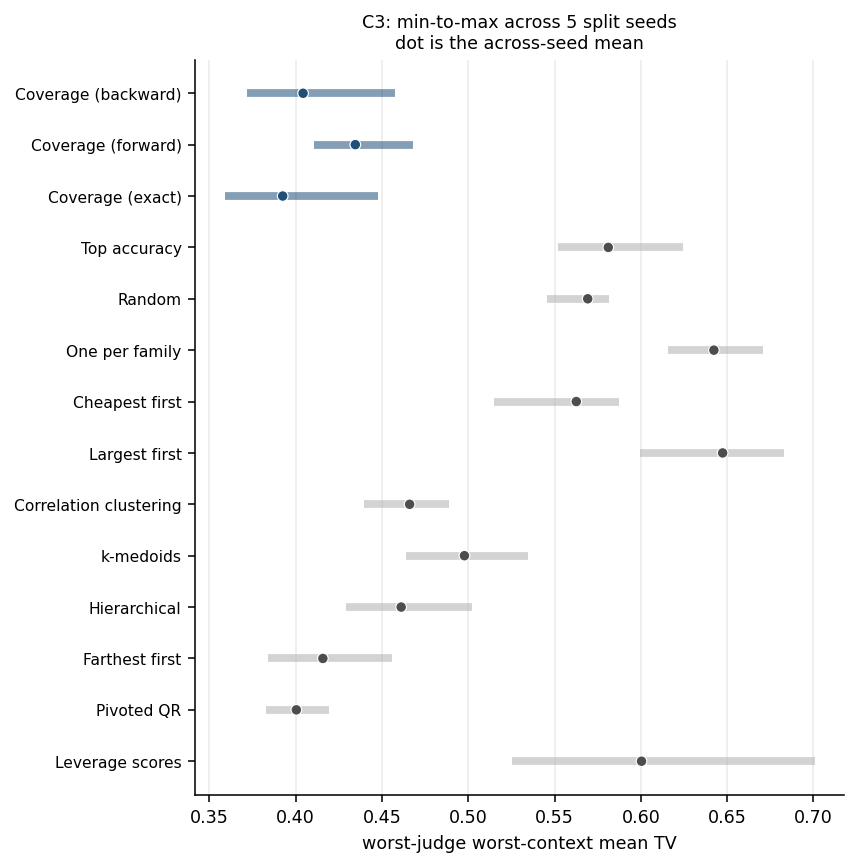

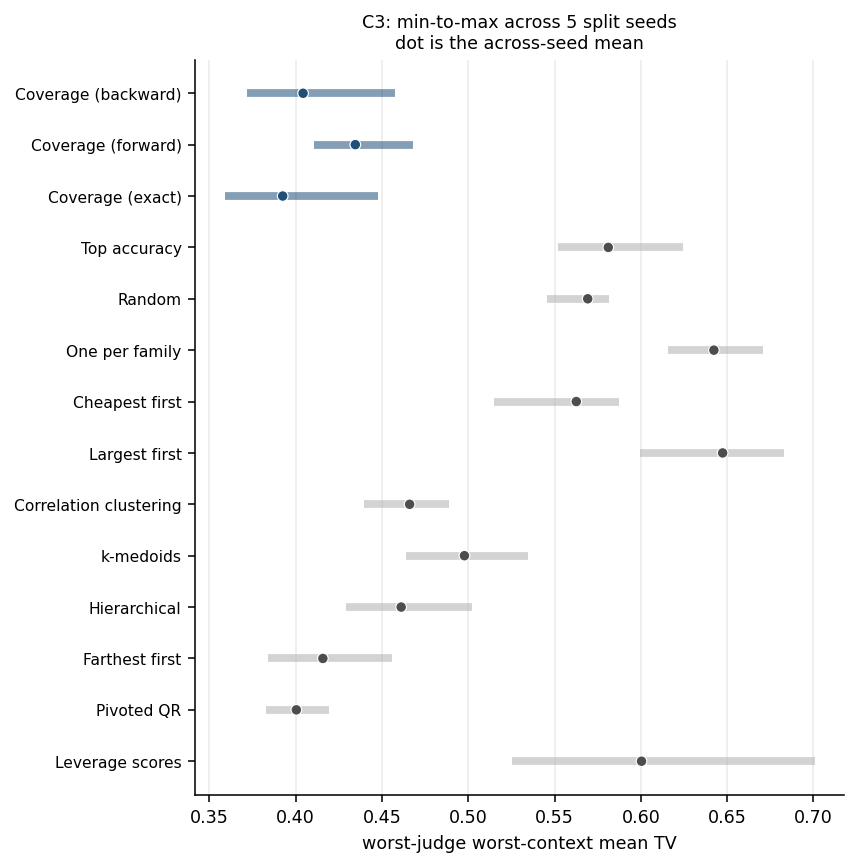

In [14]:
rob = R.c3_split_robustness(PATHS["c3"])
display(rob[["label", "mean", "sd", "min", "max", "range", "n_seeds"]])
display(F.fig_c3_split_robustness(PATHS["c3"]))

### Cost

Judges are not equally expensive, so equal-$k$ is not equal-cost. These are
measured inference seconds on the scored items, not a parameter-count proxy.

,k,worst_judge_tv,verdict_agreement,calls_avoided_frac,panel_seconds,seconds_saved,speedup
0,1,0.8841,0.3176,0.8750,119.1175,886.5336,8.4425
1,2,0.7341,0.7043,0.7500,292.3969,713.2542,3.4393
2,3,0.4071,0.8052,0.6250,382.1090,623.5420,2.6318
3,4,0.3883,0.8771,0.5000,553.9785,451.6726,1.8153
4,5,0.3339,0.9068,0.3750,657.6652,347.9858,1.5291
5,6,0.3217,0.9441,0.2500,775.5816,230.0695,1.2966
6,7,0.2404,0.9847,0.1250,905.6695,99.9816,1.1104
7,8,0.0000,1.0000,0.0000,1005.6511,0.0000,1.0000


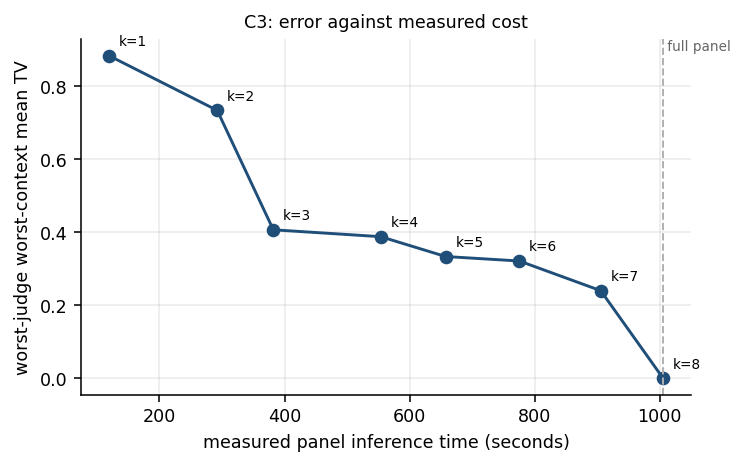

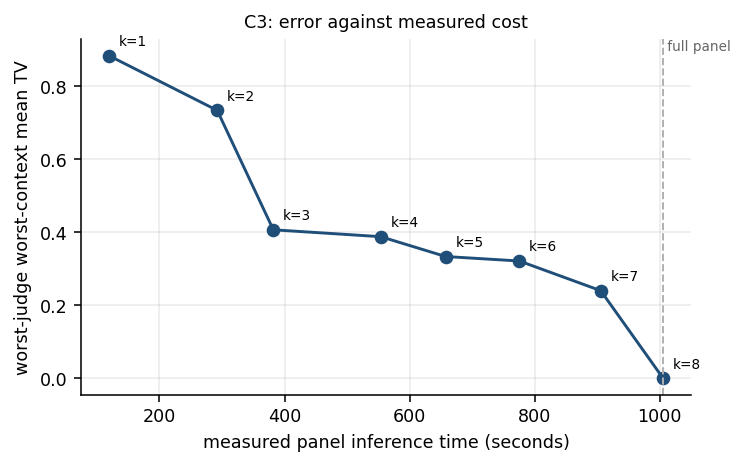

In [15]:
display(R.c3_cost_table(PATHS["c3"]))
display(F.fig_c3_cost(PATHS["c3"]))

### How much of the remaining error is unavoidable

The rank-$k$ floor is what a best-case $k$-dimensional basis achieves. It is
**not deployable** — its basis vectors are not real judges, so there is nothing
to run to produce them — but it bounds what any choice of $k$ judges could hope
for. The distance between the coverage curve and this floor is the part of the
error that is due to being restricted to real judges.

In [16]:
display(R.lowrank_floor_table(PATHS["c3"]))

,method,k,worst_judge_tv,mean_judge_tv,label
0,nmf,1,0.5810,0.4117,NMF floor (not deployable)
1,nmf,2,0.5068,0.3120,NMF floor (not deployable)
2,nmf,3,0.3294,0.2399,NMF floor (not deployable)
3,nmf,4,0.3273,0.2074,NMF floor (not deployable)
4,nmf,5,0.2757,0.1434,NMF floor (not deployable)
5,nmf,6,0.2053,0.0863,NMF floor (not deployable)
6,nmf,7,0.1404,0.0357,NMF floor (not deployable)
7,nmf,8,0.0015,0.0004,NMF floor (not deployable)
8,pca,1,0.5929,0.3653,PCA floor (not deployable)
9,pca,2,0.4416,0.3042,PCA floor (not deployable)


### The reconstruction rule matters as much as the subset

Same selected judges, five fitting rules. Unconstrained rules can score lower on
TV while leaving the simplex — their output is then not a probability
distribution and cannot be shipped as a judge verdict. `off_simplex_frac` is the
price they pay, and it is why the simplex rule is the primary one.

rule,nearest,nonneg,ridge,simplex,uniform
k,,,,,
1,0.8901,0.5786,0.5568,0.8901,0.8901
2,0.6906,0.5789,0.5571,0.6610,0.6565
3,0.5612,0.4034,0.3963,0.3816,0.5675
4,0.4158,0.3860,0.3758,0.3534,0.5833
5,0.3982,0.3221,0.3221,0.3175,0.4104
6,0.3643,0.3261,0.3261,0.3043,0.4286
7,0.2160,0.2258,0.2287,0.2186,0.3497


rule,nearest,nonneg,ridge,simplex,uniform
k,,,,,
1,0.0000,0.8750,0.8750,0.0000,0.0000
2,0.0000,0.7500,0.7500,0.0000,0.0000
3,0.0000,0.6250,0.6250,0.0000,0.0000
4,0.0000,0.5000,0.5000,0.0000,0.0000
5,0.0000,0.3750,0.3750,0.0000,0.0000
6,0.0000,0.2500,0.2500,0.0000,0.0000
7,0.0000,0.1250,0.1250,0.0000,0.0000


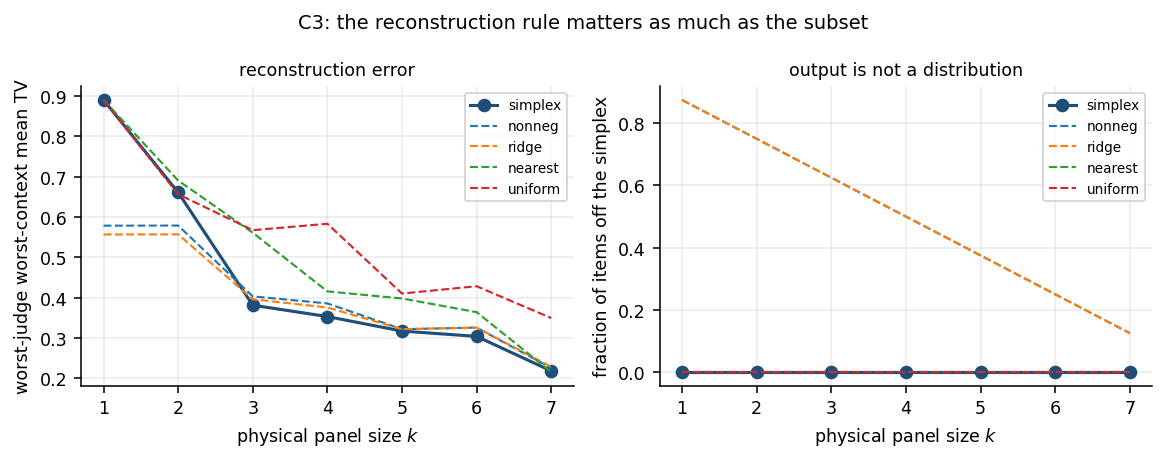

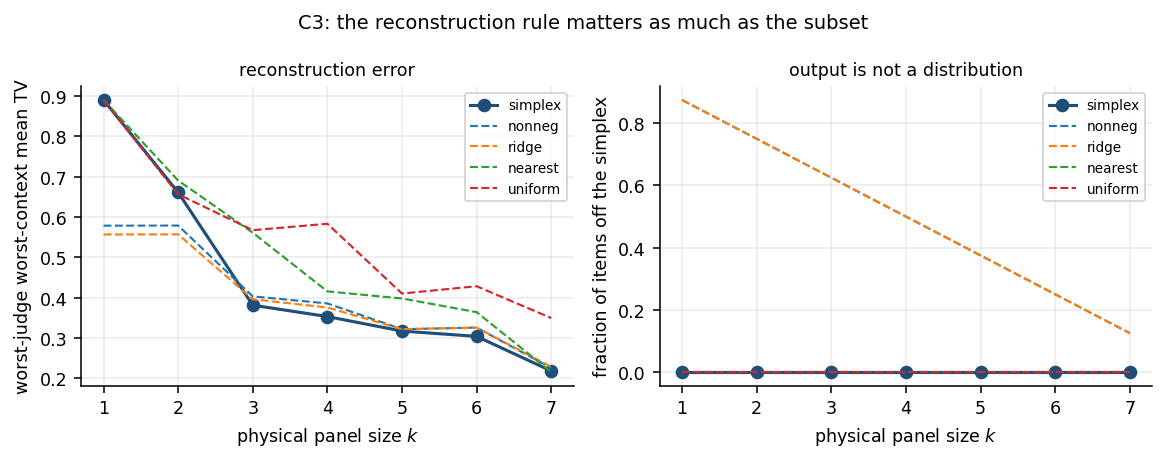

In [17]:
rec = R.reconstruction_table(PATHS["c3"])
display(rec.pivot(index="k", columns="rule", values="worst_judge_tv"))
display(rec.pivot(index="k", columns="rule", values="off_simplex_frac"))
display(F.fig_c3_reconstruction(PATHS["c3"]))

---

## Build the delivery package

Writes `results/export/<panel>/` with `tables/`, `figures/`, `raw/`,
`SUMMARY.md` and a `manifest.json` carrying a SHA-256 per file plus the git
commit, then zips it.

Everything in that zip came from the same `report.py` and `figures.py` calls
used above, so the package cannot disagree with this notebook.

In [18]:
from experiments.export_results import export

zip_path = export(PANEL)
print()
print("send this file:", zip_path)

tables:  14


figures: 8


notebooks: 4



wrote /Users/lucijajurkovic/Desktop/EPCRC/results/export/epcrc_results_core8_20260913.zip  (2.6 MB)

send this file: /Users/lucijajurkovic/Desktop/EPCRC/results/export/epcrc_results_core8_20260913.zip
